In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

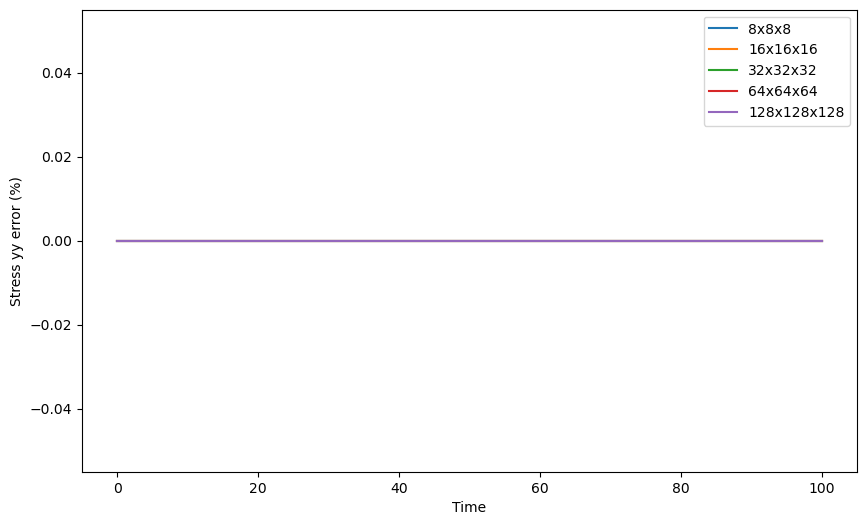

In [ ]:
stress_8 = pd.read_csv('stress_trajectories_8.txt')
stress_16 = pd.read_csv('stress_trajectories_16.txt')
stress_32 = pd.read_csv('stress_trajectories_32.txt')
stress_64 = pd.read_csv('stress_trajectories_64.txt')
stress_128 = pd.read_csv('stress_trajectories_128.txt')

plt.figure(figsize=(10, 6))
comp = 'yy'
sub = stress_128[comp]
max_stress = stress_64[comp].abs().max()

labels = ['8x8x8', '16x16x16', '32x32x32', '64x64x64', '128x128x128']
stresses = [stress_8, stress_16, stress_32, stress_64, stress_128]
for idx, stress in enumerate(stresses):
    plt.plot((stress[comp] - sub) / max_stress * 100, label=labels[idx])
plt.legend()
plt.xlabel('Time')
plt.ylabel(f'Stress {comp} error (%)')
plt.show()

/tmp/ipykernel_359305/1742502933.py:19: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')
/tmp/ipykernel_359305/1742502933.py:29: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


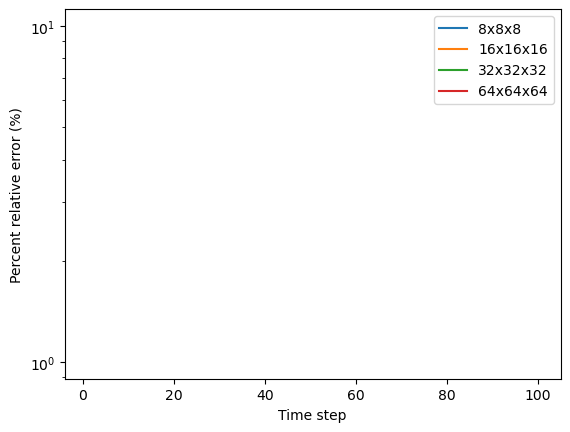

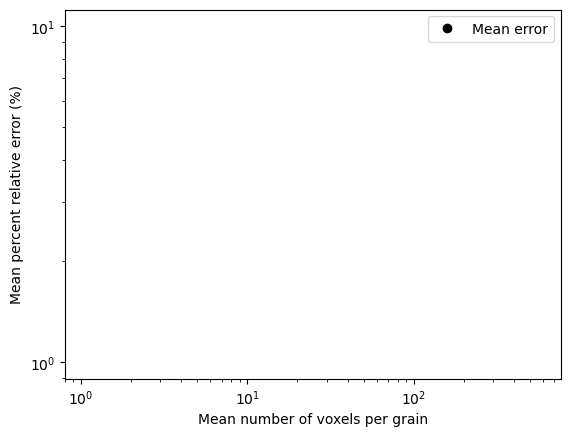

In [63]:
def compute_error(df1, df2):
    cols = ['xx', 'yy', 'zz', 'xy', 'xz', 'yz']
    error = (df1[cols] - df2[cols])**2
    summed = error.sum(axis=1)
    error = np.sqrt(summed) / np.sqrt((df2[cols]**2).sum(axis=1)) * 100
    return error

plt.figure()
mean_errors = []
for i in range(len(stresses) - 1):
    stress_1 = stresses[i]
    stress_2 = stresses[-1]
    error = compute_error(stress_1, stress_2)
    mean_errors.append(error.mean())
    plt.plot(error, label=f'{labels[i]}')
plt.legend()
plt.ylabel('Percent relative error (%)')
plt.xlabel('Time step')
plt.yscale('log')

plt.figure()
number_voxels = [8**3, 16**3, 32**3, 64**3]
number_grains = 470
plt.plot([x / number_grains for x in number_voxels], mean_errors, 'ko', label='Mean error')
plt.legend()
plt.ylabel('Mean percent relative error (%)')
plt.xlabel('Mean number of voxels per grain')
plt.xscale('log')
plt.yscale('log')